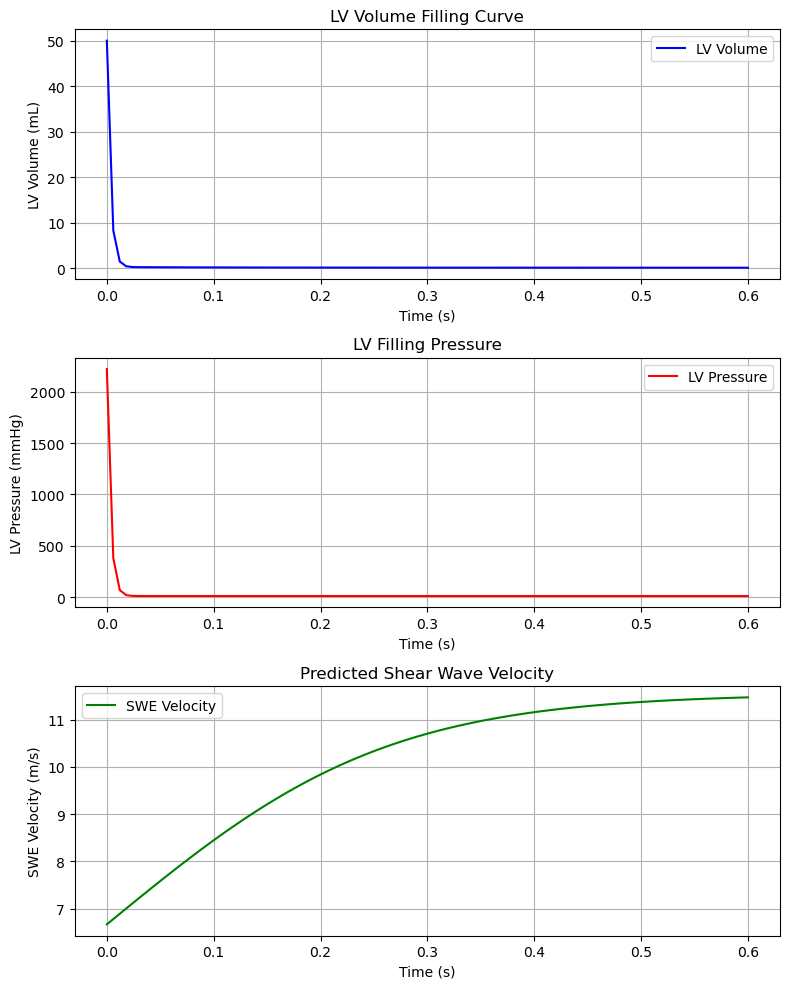

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define lumped-parameter model constants
P_LA = 10  # Left atrial pressure (mmHg)
R_mitral = 0.15  # Mitral valve resistance (mmHg·s/mL)
C_LV_base = 0.015  # Baseline LV compliance (mL/mmHg)
t_diastole = 0.6  # Duration of diastole (s)

# Define time-varying compliance function
def C_LV(t):
    """ Time-varying LV compliance function """
    C_max = C_LV_base * 1.5  # Max compliance (higher in early diastole)
    C_min = C_LV_base * 0.5  # Min compliance (lower in late diastole)
    return C_min + (C_max - C_min) * np.exp(-5 * t / t_diastole)  # Exponential decay over diastole

# ODE governing LV filling
def dV_LV_dt(t, V_LV):
    """ Governs LV volume change during filling """
    P_LV = V_LV / C_LV(t)  # LV pressure (P = V/C)
    Q_mitral = (P_LA - P_LV) / R_mitral  # Mitral valve flow
    return Q_mitral  # dV/dt = flow into LV

# Solve ODE for LV volume over diastole
t_span = (0, t_diastole)
V_LV_0 = 50  # Initial LV volume (mL)
t_eval = np.linspace(0, t_diastole, 100)
sol = solve_ivp(dV_LV_dt, t_span, [V_LV_0], t_eval=t_eval)

# Compute LV pressures and SWE velocities
V_LV = sol.y[0]  # LV volume over time
P_LV = V_LV / C_LV(sol.t)  # LV pressure (P = V/C)
SWE_velocity = np.sqrt(1 / C_LV(sol.t))  # Shear wave speed (simplified relation)

# Plot results
fig, axs = plt.subplots(3, 1, figsize=(8, 10))

# Plot LV volume over time
axs[0].plot(sol.t, V_LV, label="LV Volume", color='b')
axs[0].set_ylabel("LV Volume (mL)")
axs[0].set_xlabel("Time (s)")
axs[0].set_title("LV Volume Filling Curve")
axs[0].legend()
axs[0].grid()

# Plot LV pressure over time
axs[1].plot(sol.t, P_LV, label="LV Pressure", color='r')
axs[1].set_ylabel("LV Pressure (mmHg)")
axs[1].set_xlabel("Time (s)")
axs[1].set_title("LV Filling Pressure")
axs[1].legend()
axs[1].grid()

# Plot SWE velocity over time
axs[2].plot(sol.t, SWE_velocity, label="SWE Velocity", color='g')
axs[2].set_ylabel("SWE Velocity (m/s)")
axs[2].set_xlabel("Time (s)")
axs[2].set_title("Predicted Shear Wave Velocity")
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()


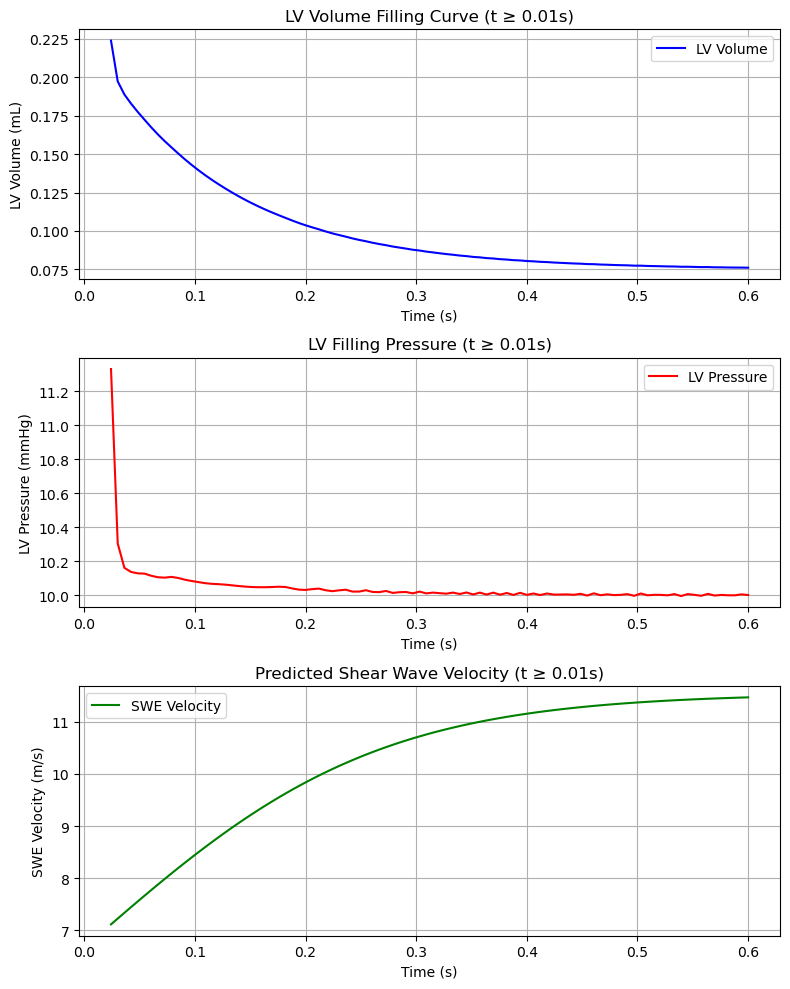

In [7]:
# Filter out values where t < 0.01 for plotting
t_display_idx = sol.t >= 0.02
t_display = sol.t[t_display_idx]
V_LV_display = V_LV[t_display_idx]
P_LV_display = P_LV[t_display_idx]
SWE_velocity_display = SWE_velocity[t_display_idx]

# Plot results without displaying t < 0.01
fig, axs = plt.subplots(3, 1, figsize=(8, 10))

# Plot LV volume over time
axs[0].plot(t_display, V_LV_display, label="LV Volume", color='b')
axs[0].set_ylabel("LV Volume (mL)")
axs[0].set_xlabel("Time (s)")
axs[0].set_title("LV Volume Filling Curve (t ≥ 0.01s)")
axs[0].legend()
axs[0].grid()

# Plot LV pressure over time
axs[1].plot(t_display, P_LV_display, label="LV Pressure", color='r')
axs[1].set_ylabel("LV Pressure (mmHg)")
axs[1].set_xlabel("Time (s)")
axs[1].set_title("LV Filling Pressure (t ≥ 0.01s)")
axs[1].legend()
axs[1].grid()

# Plot SWE velocity over time
axs[2].plot(t_display, SWE_velocity_display, label="SWE Velocity", color='g')
axs[2].set_ylabel("SWE Velocity (m/s)")
axs[2].set_xlabel("Time (s)")
axs[2].set_title("Predicted Shear Wave Velocity (t ≥ 0.01s)")
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()
